##### Classification Problem with Support Vector Regression

In [191]:
import numpy as np;
import pandas as pd;
import matplotlib.pyplot as plt;
import seaborn as sns;
from sklearn.model_selection import train_test_split,GridSearchCV;
from sklearn.linear_model import LogisticRegression;
from sklearn.preprocessing import OneHotEncoder,LabelEncoder;
from sklearn.compose import ColumnTransformer;
import pickle;
from sklearn.svm import SVR;
from plotly.express import scatter_3d; 
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score,confusion_matrix;


In [192]:
df=sns.load_dataset('iris')

In [193]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [194]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [195]:
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [196]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

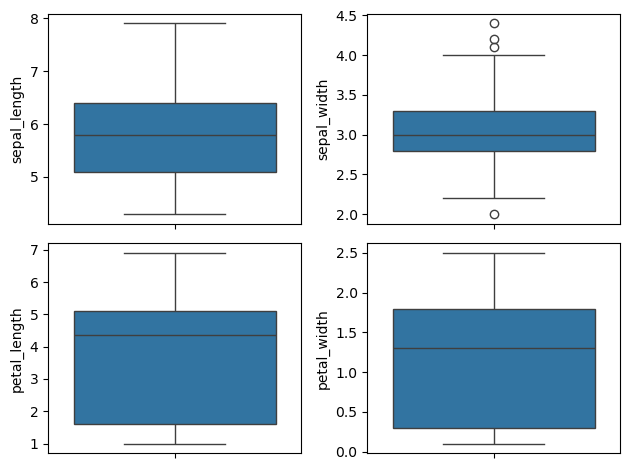

In [197]:
i=1;
for column in df.columns:
    if df[column].dtype!='O':
        plt.subplot(2,2,i)
        sns.boxplot(df[column])
        i+=1;
    plt.tight_layout()

In [198]:
IQR_sepl_witdh=df['sepal_width'].quantile(.75)-df['sepal_width'].quantile(.25)
high=df['sepal_width'].quantile(.75)+IQR_sepl_witdh*1.5
low=df['sepal_width'].quantile(.25)-IQR_sepl_witdh*1.5
high,low

(np.float64(4.05), np.float64(2.05))

In [199]:
df[df['sepal_width']>high]

,sepal_length,sepal_width,petal_length,petal_width,species
15,5.7,4.4,1.5,0.4,setosa
32,5.2,4.1,1.5,0.1,setosa
33,5.5,4.2,1.4,0.2,setosa


In [200]:
df[df['sepal_width']<low]

,sepal_length,sepal_width,petal_length,petal_width,species
60,5.0,2.0,3.5,1.0,versicolor


<Axes: xlabel='species', ylabel='Count'>

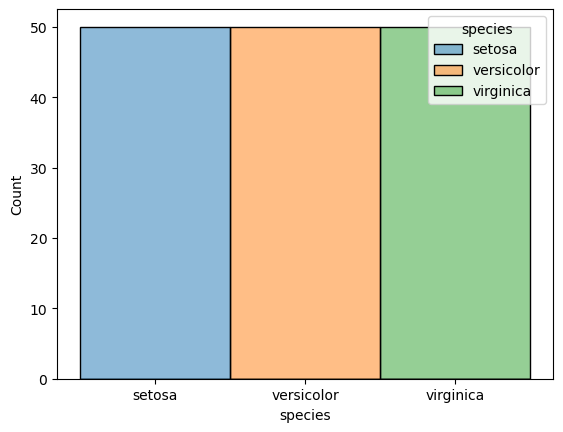

In [201]:
sns.histplot(df,x='species',hue='species')

In [202]:
x=df.drop(columns=['species'],axis=1)
y=df['species']

In [203]:
x.corr()

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


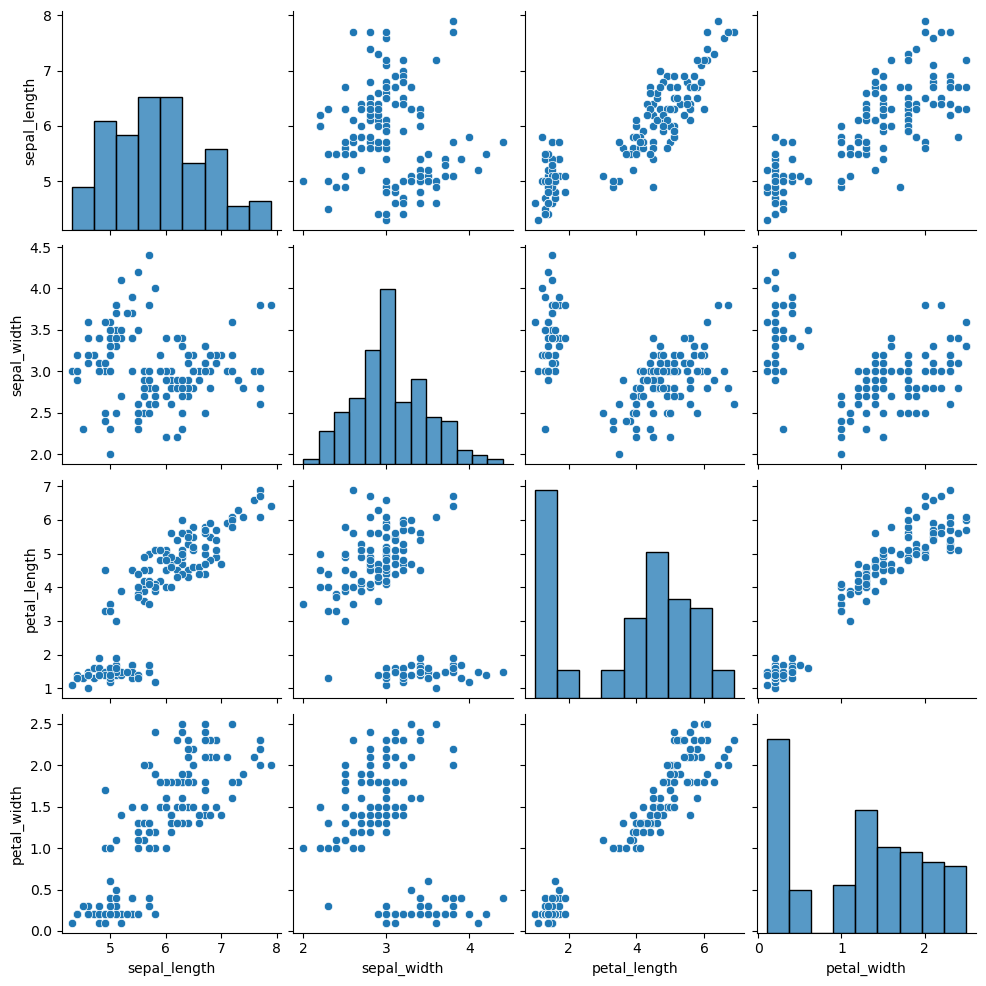

In [204]:
sns.pairplot(x)

<Axes: xlabel='petal_length', ylabel='petal_width'>

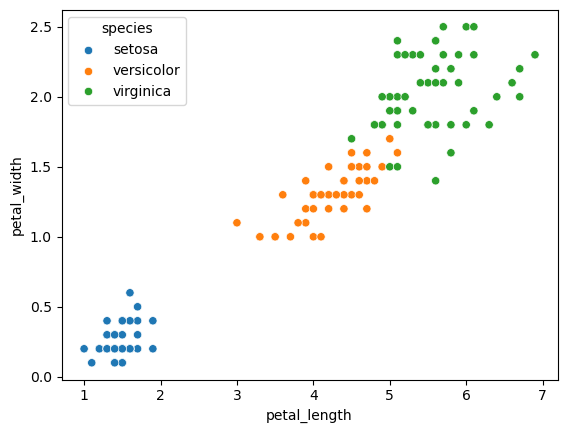

In [205]:
sns.scatterplot(df,x='petal_length',y='petal_width',hue='species')

<Axes: xlabel='sepal_length', ylabel='sepal_width'>

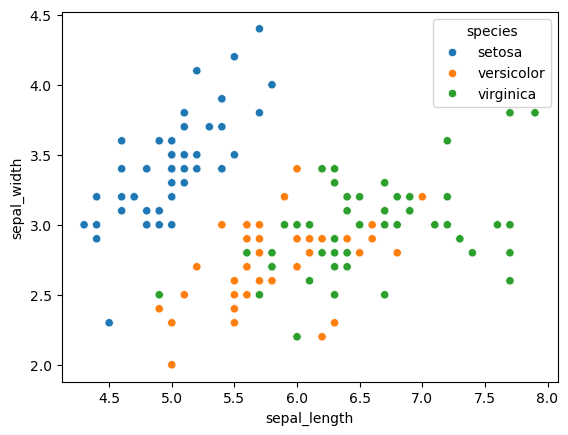

In [206]:
sns.scatterplot(df,x='sepal_length',y='sepal_width',hue='species')

In [207]:
scatter_3d(df,x='petal_length',y='petal_width',z='species')

In [208]:
scatter_3d(df,x='sepal_length',y='sepal_width',z='species')

In [209]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [210]:
le=LabelEncoder()

In [211]:
y_train_encoded=le.fit_transform(y_train)

In [212]:
le.classes_

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [213]:
y_train_encoded

array([0, 0, 2, 1, 1, 0, 0, 1, 2, 2, 1, 2, 1, 2, 1, 0, 2, 1, 0, 0, 0, 1,
       2, 0, 0, 0, 1, 0, 1, 2, 0, 1, 2, 0, 2, 2, 1, 1, 2, 1, 0, 1, 2, 0,
       0, 1, 1, 0, 2, 0, 0, 1, 1, 2, 1, 2, 2, 1, 0, 0, 2, 2, 0, 0, 0, 1,
       2, 0, 2, 2, 0, 1, 1, 2, 1, 2, 0, 2, 1, 2, 1, 1, 1, 0, 1, 1, 0, 1,
       2, 2, 0, 1, 2, 2, 0, 2, 0, 1, 2, 2, 1, 2, 1, 1, 2, 2, 0, 1, 2, 0,
       1, 2])

In [214]:
y_test_encoded=le.transform(y_test)

In [215]:
y_test

73     versicolor
18         setosa
118     virginica
78     versicolor
76     versicolor
31         setosa
64     versicolor
141     virginica
68     versicolor
82     versicolor
110     virginica
12         setosa
36         setosa
9          setosa
19         setosa
56     versicolor
104     virginica
69     versicolor
55     versicolor
132     virginica
29         setosa
127     virginica
26         setosa
128     virginica
131     virginica
145     virginica
108     virginica
143     virginica
45         setosa
30         setosa
22         setosa
15         setosa
65     versicolor
11         setosa
42         setosa
146     virginica
51     versicolor
27         setosa
Name: species, dtype: object

In [216]:
y_test_encoded

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 1, 0, 0, 2, 1, 0])

---------------Log ---------------
mse : 0.0
mae : 0.0
R2 score : 1.0


<Axes: >

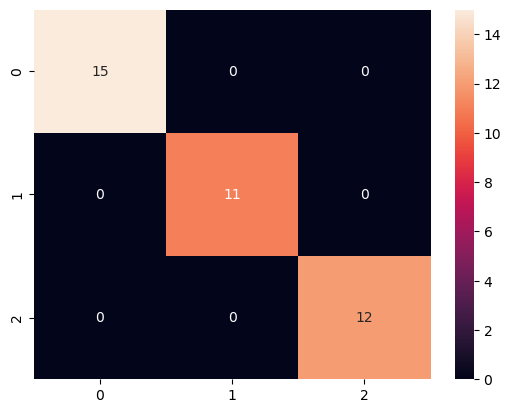

In [217]:
log=LogisticRegression(n_jobs=-1)
log.fit(x_train,y_train_encoded)
y_pred=log.predict(x_test)
mse=mean_squared_error(y_pred,y_test_encoded)
mae=mean_absolute_error(y_pred,y_test_encoded)
score=r2_score(y_pred,y_test_encoded)
cf=confusion_matrix(y_pred,y_test_encoded)
print(f'---------------Log ---------------');
print(f'mse : {mse}');
print(f'mae : {mae}');
print(f'R2 score : {score}');
sns.heatmap(cf,annot=True)




In [218]:
param_grid={
    'C':[1.0,0.1,0.001,0.0001],
    'solver': ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']
}

In [219]:
grid_log_model=GridSearchCV(estimator=LogisticRegression(n_jobs=-1),param_grid=param_grid,cv=5,scoring='accuracy')

In [220]:
import warnings;
warnings.filterwarnings('ignore')

---------------Log Grid ---------------
mse : 0.0
mae : 0.0
R2 score : 1.0


<Axes: >

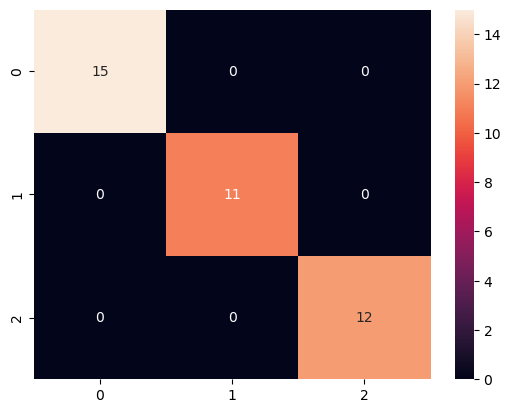

In [221]:
grid_log_model.fit(x_train,y_train_encoded)
y_grid_pred=grid_log_model.predict(x_test)
mse=mean_squared_error(y_grid_pred,y_test_encoded)
mae=mean_absolute_error(y_grid_pred,y_test_encoded)
score=r2_score(y_grid_pred,y_test_encoded)
cf=confusion_matrix(y_grid_pred,y_test_encoded)
print(f'---------------Log Grid ---------------');
print(f'mse : {mse}');
print(f'mae : {mae}');
print(f'R2 score : {score}');
sns.heatmap(cf,annot=True)

In [190]:
grid_log_model.best_params_

{'C': 1.0, 'solver': 'sag'}

In [222]:
pickle.dump(grid_log_model,open('grid_log_model.pkl','wb'))


In [228]:
pickle.dump(le,open('label_encoder.pkl','wb'))

In [ ]:
le.classes_

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [229]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [230]:
df.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica
